# W51 RGB image: F140M (B) / F405N (G) / F560W (R) with catalog sources

* Images: north-up reprojections in `reproject_to_alma_extended/`.
  These files carry `CDELT1 > 0` with an identity PC matrix, so displaying them directly puts east on the right.
  All three are reprojected here onto one common TAN grid with `CDELT1 < 0` (north up, east left) at the F405N pixel scale.
* Sources: `final_catalog_new_cfit_cut.fits` with `nmatch_bands > 3`.
* Protoclusters: W51-E and W51-IRS2 (Ginsburg et al. 2017).

In [1]:
import os
FIGDIR = '/blue/adamginsburg/t.yoo/w51_nircam/analysis/plots_for_paper/figures/rgb_f140m_f405n_f560w_sources'
os.makedirs(FIGDIR, exist_ok=True)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle
from astropy.io import fits
from astropy.wcs import WCS
from astropy.table import Table
from astropy.coordinates import SkyCoord
from astropy.visualization import simple_norm
import astropy.units as u
from reproject import reproject_interp
from scipy.ndimage import binary_fill_holes, distance_transform_edt
import warnings
from astropy.wcs import FITSFixedWarning
warnings.simplefilter('ignore', FITSFixedWarning)

In [2]:
image_dir = '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/reproject_to_alma_extended/'
catalog_fn = '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/final_catalog_new_cfit_cut.fits'
cache_fn = '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/rgbs/rgb_f560w_f405n_f140m_northup_cube.fits'
outdir = FIGDIR

# R, G, B
rgb_filters = ['f560w', 'f405n', 'f140m']
image_filenames = {f: os.path.join(image_dir, f'{f}_reprojected_to_alma.fits') for f in rgb_filters}

distance = 5.4 * u.kpc  # Sato et al. 2010

## Common north-up grid and reprojection (cached)

In [3]:
# F405N pixel scale; footprint covers the NIRCam field
pixscale = abs(fits.getheader(image_filenames['f405n'])['CDELT1'])  # deg/pix
ra_min, ra_max = 290.8855, 290.9655
dec_min, dec_max = 14.4595, 14.5675
ra_c, dec_c = 0.5 * (ra_min + ra_max), 0.5 * (dec_min + dec_max)
nx = int(np.ceil((ra_max - ra_min) * np.cos(np.deg2rad(dec_c)) / pixscale))
ny = int(np.ceil((dec_max - dec_min) / pixscale))

wcs_out = WCS(naxis=2)
wcs_out.wcs.ctype = ['RA---TAN', 'DEC--TAN']
wcs_out.wcs.crval = [ra_c, dec_c]
wcs_out.wcs.cdelt = [-pixscale, pixscale]   # east left, north up
wcs_out.wcs.crpix = [nx / 2 + 0.5, ny / 2 + 0.5]
wcs_out.wcs.cunit = ['deg', 'deg']
print(nx, ny, pixscale * 3600, 'arcsec/pix')

4430 6178 0.0629389136717244 arcsec/pix


In [4]:
if os.path.exists(cache_fn):
    channels = fits.getdata(cache_fn)
else:
    channels = []
    for f in rgb_filters:
        with fits.open(image_filenames[f]) as hdul:
            arr, _ = reproject_interp((hdul[0].data.astype(np.float32), WCS(hdul[0].header)),
                                      wcs_out, shape_out=(ny, nx), order='bilinear')
        channels.append(arr.astype(np.float32))
        print(f'{f} reprojected')
    channels = np.array(channels)
    fits.PrimaryHDU(channels, header=wcs_out.to_header()).writeto(cache_fn, overwrite=True)
channels.shape

(3, 6178, 4430)

## RGB composite

In [5]:
# per-channel asinh stretch: (min %, max %, asinh_a)
stretch_pars = {'f560w': (1, 99.7, 0.05),
                'f405n': (1, 99.7, 0.05),
                'f140m': (1, 99.7, 0.05)}

rgb = np.zeros((ny, nx, 3), dtype=np.float32)
for i, f in enumerate(rgb_filters):
    ch = channels[i].copy()
    finite = np.isfinite(ch)
    # NaN holes inside the footprint (e.g. saturated cores): fill with the nearest valid pixel
    holes = binary_fill_holes(finite) & ~finite
    _, (iy, ix) = distance_transform_edt(~finite, return_indices=True)
    ch[holes] = ch[iy[holes], ix[holes]]
    pmin, pmax, a = stretch_pars[f]
    vmin, vmax = np.nanpercentile(ch, [pmin, pmax])
    norm = simple_norm(ch, stretch='asinh', vmin=vmin, vmax=vmax, asinh_a=a)
    rgb[..., i] = np.clip(np.nan_to_num(np.asarray(norm(ch), dtype=np.float32)), 0, 1)

## Catalog sources and protoclusters

In [6]:
cat = Table.read(catalog_fn)
sel = cat['nmatch_bands'] > 3
src = cat['skycoord_ref'][sel]
print(f'{sel.sum()} / {len(cat)} sources with nmatch_bands > 3')

# protocluster positions (Ginsburg et al. 2017): W51e2 complex and W51 North / IRS2
protoclusters = {
    'W51-E':    SkyCoord('19h23m43.95s', '+14d30m34.0s', frame='icrs'),
    'W51-IRS2': SkyCoord('19h23m39.90s', '+14d31m05.0s', frame='icrs'),
}
protocluster_radius = 8 * u.arcsec  # display radius only

15004 / 15004 sources with nmatch_bands > 3


In [7]:
def add_scalebar(ax, wcs, length_pc, distance, x0, y0, color='white', fontsize=14, lw=4):
    """Horizontal ruler starting at axes-fraction (x0, y0)."""
    length_ang = (length_pc * u.pc / distance).to(u.arcsec, u.dimensionless_angles())
    pixscale = wcs.proj_plane_pixel_scales()[0].to(u.arcsec)
    length_pix = (length_ang / pixscale).decompose().value
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    xs = xlim[0] + x0 * (xlim[1] - xlim[0])
    ys = ylim[0] + y0 * (ylim[1] - ylim[0])
    ax.plot([xs, xs + length_pix], [ys, ys], color=color, lw=lw, solid_capstyle='butt')
    ax.text(xs + length_pix / 2, ys + 0.012 * (ylim[1] - ylim[0]),
            f'{length_pc:g} pc ({length_ang.value:.1f}\")', color=color,
            fontsize=fontsize, ha='center', va='bottom')


def add_compass(ax, wcs, x0, y0, length_frac=0.07, color='white', fontsize=14):
    """N/E arrows from axes-fraction (x0, y0), directions taken from the WCS."""
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    xc = xlim[0] + x0 * (xlim[1] - xlim[0])
    yc = ylim[0] + y0 * (ylim[1] - ylim[0])
    L = length_frac * (ylim[1] - ylim[0])
    c0 = wcs.pixel_to_world(xc, yc)
    for label, pa in [('N', 0 * u.deg), ('E', 90 * u.deg)]:
        c1 = c0.directional_offset_by(pa, 1 * u.arcsec)
        x1, y1 = wcs.world_to_pixel(c1)
        d = np.array([x1 - xc, y1 - yc])
        d = d / np.hypot(*d) * L
        ax.annotate('', xy=(xc + d[0], yc + d[1]), xytext=(xc, yc),
                    arrowprops=dict(arrowstyle='-|>', color=color, lw=2, mutation_scale=18))
        ax.text(xc + 1.25 * d[0], yc + 1.25 * d[1], label, color=color,
                fontsize=fontsize, ha='center', va='center')

## Figure

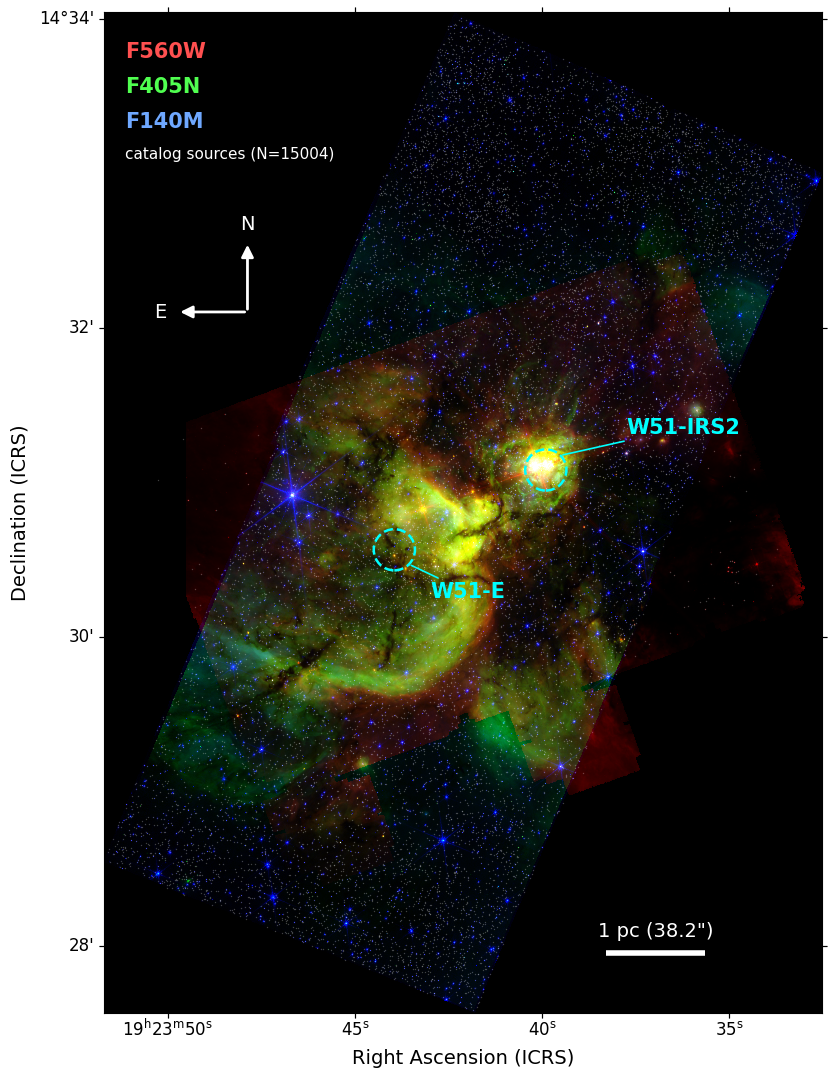

In [8]:
fig = plt.figure(figsize=(10, 13))
ax = fig.add_subplot(111, projection=wcs_out)
ax.imshow(rgb, origin='lower', interpolation='nearest')

# catalog sources: small, faint dots
xs, ys = wcs_out.world_to_pixel(src)
ax.scatter(xs, ys, s=1.0, color='white', alpha=0.25, lw=0, rasterized=True)

# protoclusters
pixscale_arcsec = wcs_out.proj_plane_pixel_scales()[0].to(u.arcsec).value
label_offset = {'W51-E': (220, -260), 'W51-IRS2': (500, 260)}  # pixels
for name, coord in protoclusters.items():
    x, y = wcs_out.world_to_pixel(coord)
    r = protocluster_radius.to(u.arcsec).value / pixscale_arcsec
    ax.add_patch(Circle((x, y), r, fill=False, ec='cyan', lw=1.8, ls='--'))
    dx, dy = label_offset[name]
    ax.annotate(name, xy=(x + r * np.sign(dx) * 0.7, y + r * np.sign(dy) * 0.7),
                xytext=(x + dx, y + dy), color='cyan', fontsize=15, fontweight='bold',
                ha='left' if dx > 0 else 'right', va='center',
                arrowprops=dict(arrowstyle='-', color='cyan', lw=1.2))

ax.set_xlim(0, nx - 1)
ax.set_ylim(0, ny - 1)

# filter labels
for i, (f, c) in enumerate(zip(['F560W', 'F405N', 'F140M'], ['#ff5050', '#50ff50', '#6fa8ff'])):
    ax.text(0.03, 0.97 - 0.035 * i, f, color=c, fontsize=15, fontweight='bold',
            transform=ax.transAxes, ha='left', va='top')
ax.text(0.03, 0.97 - 0.035 * 3, f'catalog sources (N={sel.sum()})', color='white',
        fontsize=11, transform=ax.transAxes, ha='left', va='top')

add_compass(ax, wcs_out, x0=0.20, y0=0.70)
add_scalebar(ax, wcs_out, 1, distance, x0=0.70, y0=0.06)

ax.coords['ra'].set_axislabel('Right Ascension (ICRS)', fontsize=14)
ax.coords['dec'].set_axislabel('Declination (ICRS)', fontsize=14)
ax.coords['ra'].set_ticklabel(size=12)
ax.coords['dec'].set_ticklabel(size=12)

fig.savefig(os.path.join(outdir, 'rgb_f140m_f405n_f560w_sources_cfit003.png'), dpi=200, bbox_inches='tight')
fig.savefig(os.path.join(outdir, 'rgb_f140m_f405n_f560w_sources_cfit003.pdf'), dpi=200, bbox_inches='tight')
plt.show()